# Parametric Rainfall Insurance — Stochastic Loss Simulation for Weather-Linked Products
### Insurance Loss Simulation

This is the final notebook of the project **"Parametric Rainfall Insurance — Stochastic Loss Simulation for Weather-Linked Products"**

The prametric insurance product defined here is an insurance product that pays out a fixed amount if the monthly rainfall in this given region is more than the defined triggers and exit points. 

This notebook takes 1,000 siulated daily rainfalls for one year period and applies the parametric insurance structure to the aggregate monthly rainfall. The insurance payout is defined as:

<div align="center">

$$
\text{Payout} = \begin{cases} 0 & \text{if } X < T \\ 10{,}000 \times \dfrac{X - T}{M - T} & \text{if } T \leq X \leq M \\ 10{,}000 & \text{if } X > M \end{cases}
$$

*Where X is monthly aggregate rainfall, T is the trigger and M is the exit point.*

</div>

For monthly aggregate rainfalls, we continue to compare both approaches from previous notebook by looking at expected annual loss amount (pure risk premium) and variability around this point estimate. The notebook does not cover for expenses and profit loading on top of the base loss cost. 

In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import datetime
from tweedie import tweedie
import import_ipynb
import importlib
import random
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning

In [2]:
# Suppress statsmodels ValueWarning (no frequency)
warnings.filterwarnings("ignore", category=ValueWarning)

# Suppress pandas FutureWarning (Series indexing)
warnings.filterwarnings("ignore", category=FutureWarning)

#Import other notebooks
rainfall_distribution_notebook = importlib.import_module("01_RainfallDistribution")
stochastic_rain_path_notebook = importlib.import_module("02_StochasticRainPath")

In [3]:
#Load rainfall data
rainfall_data = rainfall_distribution_notebook.rainfall_data

In [4]:
#Set triggers for parametric insurance
aggreagte_rainfall = rainfall_data.groupby([' YEAR', ' MONTH'])[' PRECIPITATION'].sum().reset_index()
trigger_1 = np.percentile(aggreagte_rainfall[' PRECIPITATION'], 90)
exit_point = np.percentile(aggreagte_rainfall[' PRECIPITATION'], 99)

The trigger point is set at 90th percentile of monthly rainfall data and the exit point is set at 99th percentile.

In [5]:
#Simulate monthly insurance loss payout
loss_amounts_tweedie = np.zeros((stochastic_rain_path_notebook.number_of_paths, 12))
loss_amounts_occ_gamma = np.zeros((stochastic_rain_path_notebook.number_of_paths, 12))
monthly_aggregate_rainfall_tweedie = stochastic_rain_path_notebook.monthly_rainfall_tweedie
monthly_aggregate_rainfall_occ_gamma = stochastic_rain_path_notebook.monthly_rainfall_occ_gamma

#Simulate Losses using Approach A
for i in range(stochastic_rain_path_notebook.number_of_paths):
    for j in range(12):
        if monthly_aggregate_rainfall_tweedie[i,j]<trigger_1:
            loss_amounts_tweedie[i,j] = 0
        elif monthly_aggregate_rainfall_tweedie[i,j]>exit_point:
            loss_amounts_tweedie[i,j] = 10000
        else:
            loss_amounts_tweedie[i,j] = 10000*(monthly_aggregate_rainfall_tweedie[i,j]-trigger_1)/(exit_point-trigger_1)

#Simulate Losses using Approach B
for i in range(stochastic_rain_path_notebook.number_of_paths):
    for j in range(12):
        if monthly_aggregate_rainfall_occ_gamma[i,j]<trigger_1:
            loss_amounts_occ_gamma[i,j] = 0
        elif monthly_aggregate_rainfall_occ_gamma[i,j]>exit_point:
            loss_amounts_occ_gamma[i,j] = 10000
        else:
            loss_amounts_occ_gamma[i,j] = 10000*(monthly_aggregate_rainfall_occ_gamma[i,j]-trigger_1)/(exit_point-trigger_1)

In [6]:
#Aggregate the monthly loss amounts to annual losses
annual_loss_tweedie = loss_amounts_tweedie.sum(axis=1)
annual_loss_occ_gamma = loss_amounts_occ_gamma.sum(axis=1)

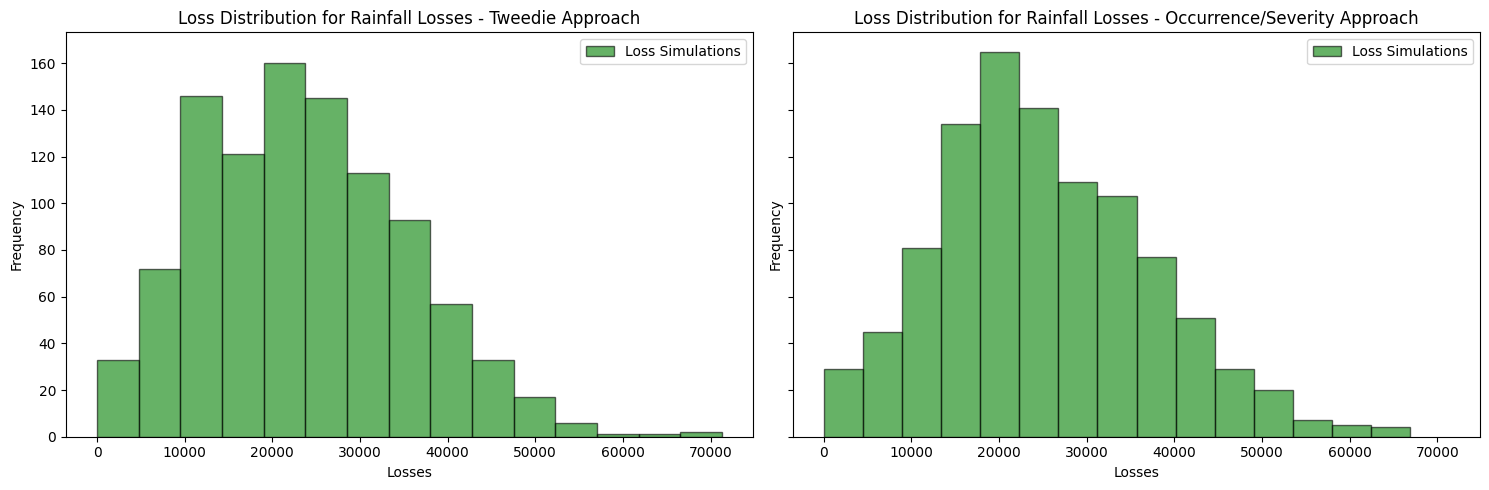

In [7]:
#Plot the histogram of distribution of Rainfall Losses
fig, axes = plt.subplots(1,2,figsize=(15,5), sharey=True, sharex=True)
axes[0].hist(annual_loss_tweedie, bins=15, alpha=0.6, color='g', label='Loss Simulations', edgecolor='black')
axes[0].legend()
axes[0].set_xlabel('Losses')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Loss Distribution for Rainfall Losses - Tweedie Approach')

axes[1].hist(annual_loss_occ_gamma, bins=15, alpha=0.6, color='g', label='Loss Simulations', edgecolor='black')
axes[1].legend()
axes[1].set_xlabel('Losses')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Loss Distribution for Rainfall Losses - Occurrence/Severity Approach')

plt.tight_layout()
plt.show()

Both models produce broadly similar loss distributions concentrated between 10,000 and 35,000 with comparable modal values around 20,000 to 25,000, confirming that once a consistent sample period is applied both approaches are well calibrated and yield materially similar premium estimates. The Occurrence/Gamma distribution appears slightly more spread out with a heavier right tail extending toward 70,000, suggesting it assigns marginally higher probability to extreme loss years, while Tweedie's distribution is slightly more concentrated around the modal range. The close alignment of the two distributions across both approaches provides confidence in the robustness of the premium estimates.

In [12]:
#Diagnostics
print(f"Trigger: {trigger_1:.4f}")
print(f"Exit: {exit_point:.4f}")
print(f"Tweedie mean monthly: {monthly_aggregate_rainfall_tweedie.mean():.4f}")
print(f"Gamma mean monthly: {monthly_aggregate_rainfall_occ_gamma.mean():.4f}")
print(f"Tweedie median monthly: {np.median(monthly_aggregate_rainfall_tweedie):.4f}")
print(f"Gamma median monthly: {np.median(monthly_aggregate_rainfall_occ_gamma):.4f}")
print(f"% Tweedie months > trigger: {(monthly_aggregate_rainfall_tweedie > trigger_1).mean():.4f}")
print(f"% Gamma months > trigger: {(monthly_aggregate_rainfall_occ_gamma > trigger_1).mean():.4f}")
print(f"Expected monthly loss Tweedie: {loss_amounts_tweedie.mean():.4f}")
print(f"Expected monthly loss Gamma: {loss_amounts_occ_gamma.mean():.4f}")

Trigger: 10.2880
Exit: 19.6754
Tweedie mean monthly: 9.3993
Gamma mean monthly: 9.4371
Tweedie median monthly: 7.1554
Gamma median monthly: 7.3057
% Tweedie months > trigger: 0.3387
% Gamma months > trigger: 0.3569
Expected monthly loss Tweedie: 1958.2377
Expected monthly loss Gamma: 2089.8940


In [8]:
#Mean Loss (Pure Risk Premium)
print(f"The expected loss is: ${annual_loss_tweedie.mean():.2f}")
print(f"The expected loss is: ${annual_loss_occ_gamma.mean():.2f}")

The expected loss is: $23498.85
The expected loss is: $25078.73


In [14]:
#Risk Measures - Approach A
percentile_90_a = np.percentile(annual_loss_tweedie, 90)
percentile_95_a = np.percentile(annual_loss_tweedie, 95)
print(f"The 90th percentile loss for Approach A is: ${percentile_90_a:.2f}.")
print(f"The 95th percentile loss for Approach A is ${percentile_95_a:.2f}.")

#Risk Measures - Approach B
percentile_90_b = np.percentile(annual_loss_occ_gamma, 90)
percentile_95_b = np.percentile(annual_loss_occ_gamma, 95)
print(f"The 90th percentile loss for Approach B is ${percentile_90_b:.2f}.")
print(f"The 95th percentile loss for Approach B is ${percentile_95_b:.2f}.")

The 90th percentile loss for Approach A is: $38982.85.
The 95th percentile loss for Approach A is $43454.19.
The 90th percentile loss for Approach B is $40969.42.
The 95th percentile loss for Approach B is $46756.07.


In [15]:
#Payout Frequency
payout_frequency = (annual_loss_tweedie > 0).mean()
print(f"Probability of at least one payout in a year: {payout_frequency:.1%}")

Probability of at least one payout in a year: 99.6%


The simulated expected annual loss is around $23,000 for a contract limit of $120,000. The relatively high expected loss reflects the frequency of extreme rainfall events generated by the stochastic rainfall model. The risk premium for this should therefore be around $23,000 for a year. The actual insurance premium would add for expenses and profit loading along with underwriting considerations and market conditions.

The probabillity of loss in any one year is quite high (almost 100%). 

The loss estimates in this notebook should be interpreted with caution. The stochastic rainfall model exhibits heavier tails than historical data, as identified in notebook 02. This leads to more frequent trigger breaches in the simulated paths than would be expected historically, resulting in an upward bias in the pure risk premium.

In [18]:
#Sensitivity of annual losses to different trigger points (Only done for Approach A)
trigger_percentiles = [80, 85, 90, 95, 99]
results_tweedie = []

for pct in trigger_percentiles:
    t = np.percentile(aggreagte_rainfall[' PRECIPITATION'], pct)
    m = np.percentile(aggreagte_rainfall[' PRECIPITATION'], 99)
    
    losses = np.zeros((stochastic_rain_path_notebook.number_of_paths, 12))
    for i in range(stochastic_rain_path_notebook.number_of_paths):
        for j in range(12):
            if monthly_aggregate_rainfall_tweedie[i,j] < t:
                losses[i,j] = 0
            elif monthly_aggregate_rainfall_tweedie[i,j] > m:
                losses[i,j] = 10000
            else:
                losses[i,j] = 10000 * (monthly_aggregate_rainfall_tweedie[i,j] - t) / (m - t)
    
    annual = losses.sum(axis=1)
    results_tweedie.append({
        'Trigger Percentile': f'{pct}th',
        'Trigger Value': round(t, 2),
        'Pure Risk Premium ($)': round(annual.mean(), 2),
        '90th Pct Loss ($)': round(np.percentile(annual, 90), 2),
        '99th Pct Loss ($)': round(np.percentile(annual, 99), 2),
        'Payout Frequency': f"{(annual > 0).mean():.1%}"
    })

sensitivity_df = pd.DataFrame(results_tweedie)
display(sensitivity_df)

,Trigger Percentile,Trigger Value,Pure Risk Premium ($),90th Pct Loss ($),99th Pct Loss ($),Payout Frequency
0,80th,8.03,28096.25,43731.22,56413.60,99.9%
1,85th,8.87,26287.47,41775.16,54348.91,99.8%
2,90th,10.29,23498.85,38982.85,51838.50,99.6%
3,95th,12.47,19902.79,35278.14,48501.64,97.7%
4,99th,19.68,12420.00,30000.00,40000.00,74.0%


The results in this sensitivity analysis are consistent with what we expected. The simulated paths overestimate the rainfall and so there's a payout in almost each year. In reality, this may not be true and hence this is an important limitation of our analysis. We might have to revisit the methodology for simulating rainfall paths given the tails are very heavy. 

### End of Notebook